In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

rng = np.random.default_rng(42)

exp_results.head()
      before     after
0  0.850586  1.100480
1  1.109104  1.423502
2  1.285461  1.098532
3  1.077887  1.033048
4  1.269408  1.238680

exp_results['increase'].describe()
 count    40.000000
mean      0.063628
std       0.266251
min      -0.667366
25%      -0.118254
50%       0.027598
75%       0.272667
max       0.501296
Name: increase, dtype: float64


<Axes: >

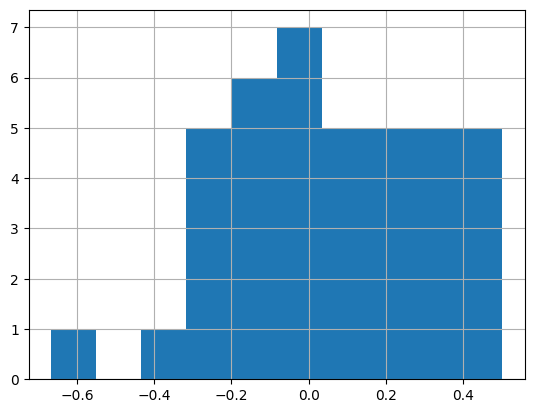

In [2]:
# Classical Statistical Inference

# We now have enough machinery to remove some of the mystery surrounding classical statistical inference. If you're like most people, 
# p-values and null hypotheses were a bit mysterious when you first learned about them. If you think about them in terms of sampling distributions, 
# which we can simulate, hopefully they will become clearer.

# The key steps are:
    # 1. Make some assumption about the process by which your sample of data was generated (the null hypothesis)
    # 2. Simulate the sampling distribution for that data generation process
    #     - Simulate a bunch of alternative data samples based on that sample
    #     - Compute the sample statistic for each
    #     - Plot the density (frequency) of different outcomes
    # 3. Assess how surprising your actual sample statistic is, with reference to that sampling distribution
    #     - Quantify that as the p-value
    #     - If the p-value is below some threshold (the significance threshold), reject the original null hypothesis



# Scenario: A Reaction Time Experiment

# Let's consider a pretty common scenario for statistical inference. You've conducted a psychology experiment, with 40 subjects, to test if 
# drinking one beer is enough to noticeably degrade their reaction times.
# We test reaction times using a computer apparatus. Images and numbers appear on the screen; When a red circle shows up, the person hits a button. 
# The amount of time elapsed from the red circle appearing until they hit the button is their reaction time.

# For each subject, we measure their reaction time (the Before measure), then have them drink one beer, then test their reaction time again (the After measure).

# We want to know whether the After measure is generally bigger than the Before measure. But there could be some random noise. 
# For some people, they might be a little distracted during the Before test, and for others during the After test.

# Let's look at an imaginary dataframe showing the results of this hypothetical experiment.

exp_results = pd.read_csv('data/reaction_times.csv')
print("exp_results.head()\n",exp_results.head())

exp_results['increase'] = exp_results['after'] - exp_results['before']
print("\nexp_results['increase'].describe()\n",exp_results['increase'].describe())

exp_results['increase'].hist()


In [3]:
# Is the Increased Reaction Time Statistically Significant?
# OK. There's an increased reaction time, on average, of about 0.06 seconds.

# How confident are we, however, that this difference is "real"? Might it be possible that on average, in the whole population, people's reactions 
# don't increase after one beer, but we happened to get a sample of 40 people that doesn't reflect the overall population or unusual reaction times 
# for them (maybe their cell phone started ringing during the test)?

# Of course, that is possible. But how plausible it?
# With Null Hypothesis Statistical Testing, we actually ask a slightly different question. Suppose that one beer has absolutely no effect on average 
# across the population. How surprised would be to see a result as extreme as we saw, 0.06 seconds?



In [4]:
# Articulating the Null Hypothesis as a Distribution (Data Generation Process)

# Given our dataframe exp_results, I'm going to show you two different ways that we could formulate the null hypothesis in a way that allows us to 
# generate lots of simulated experiments.


# 1a. Parametric Assumption: Change in Reaction Time Follows a Normal Distribution
# Our first approach will be to assume that each person's change in reaction times from Before to After is an independent draw from a Normal Distribution.

# We will assume it has mean 0 (the null hypothesis is that the mean difference is 0). For the variance of that assumed null distribution, 
# we will make our best guess, which is the empirical variance we saw in our exp_results dataset.

actual_mean = exp_results['increase'].mean()
actual_std = exp_results['increase'].std()
actual_mean, actual_std

(np.float64(0.06362840537138195), np.float64(0.26625096170556667))

In [5]:
# One simulated sample of 40
rng.normal(0, actual_std, 40)

array([ 0.08113122, -0.27689677,  0.19980835,  0.25042626, -0.519465  ,
       -0.34670655,  0.03403763, -0.08419989, -0.00447332, -0.22712377,
        0.23414056,  0.20708785,  0.01758074,  0.30012906,  0.12447481,
       -0.22878744,  0.09818025, -0.25530341,  0.23388824, -0.01329282,
       -0.04921978, -0.18129815,  0.32550281, -0.04114362, -0.11404269,
       -0.0937559 ,  0.14172783,  0.09729983,  0.10989045,  0.11470651,
        0.57021573, -0.10820839, -0.13638512, -0.21666777,  0.16400511,
        0.30058996, -0.03033862, -0.22369247, -0.21951892,  0.17322096])

In [6]:
# 2a. Simulate Sampling Distribution
# Now we will simulate lots of samples of size 40, and compute the mean of each sample.
n_simulations=50000

# Remember these two useful functions from previous notebooks
def simulate_sampling_distribution(
    underlying_distribution_simulator, sample_statistic, n_simulations=1000, sample_size=100
):
    samples = [underlying_distribution_simulator(sample_size) for _ in range(n_simulations)]
    return pd.DataFrame(
        {
            "statistic": [sample_statistic(sample) for sample in samples],
        }
    )

# plot the histogram of a dataset generated from a continuous distribution, by binning the data
def plot_continuous(data, ax, colname="statistic", num_bins=100, min_x=None, max_x=None):
    sns.histplot(data[colname], ax=ax, stat="probability")

    # Set the range of the x-axis if min_x and max_x are provided
    if min_x is not None and max_x is not None:
        ax.set_xlim(min_x, max_x)

    ax.set_ylabel("Probability")


In [7]:
sample_means_a = simulate_sampling_distribution(
    lambda n: rng.normal(0, actual_std, n),
    lambda x: x.mean(),
    n_simulations=n_simulations,
    sample_size=40,
)

sample_means_a.describe()

,statistic
count,50000.000000
mean,0.000148
std,0.041914
min,-0.201648
25%,-0.028246
50%,0.000025
75%,0.028608
max,0.169981


In [8]:
# 3a. Assess Surprise (Significance)
# Compute the p-value. What fraction of the sample means are farther from the true mean than the observed mean's distance?

# two-sided p-value, so check if absolute value of the difference
p_value_a = (np.abs(sample_means_a["statistic"]) >= abs(actual_mean)).mean()
p_value_a

np.float64(0.12862)

Text(0.5, 1.0, 'Parameteric Null Hypothesis')

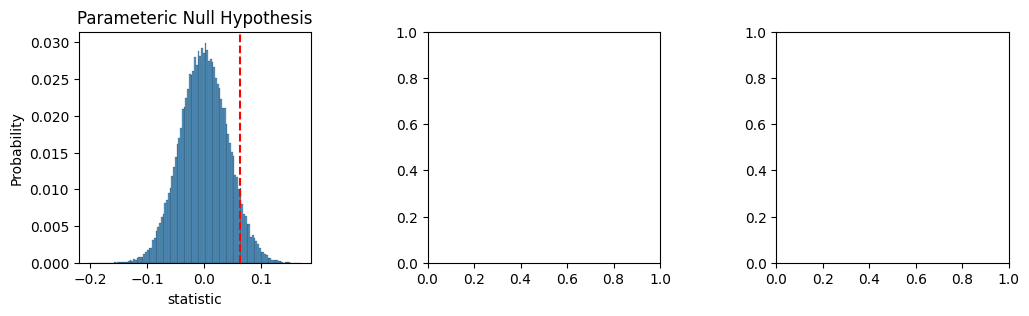

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
plt.subplots_adjust(wspace=0.5)
plot_continuous(sample_means_a, axes[0], num_bins=100)

# add a vertical line at the actual mean
axes[0].axvline(actual_mean, color="red", linestyle="--")
axes[0].set_title('Parameteric Null Hypothesis')

In [10]:
# A Different Simulation of the Null Hypothesis

# 1b. Nonparametric Null Hypothesis Using Permutation Sampling

# Again imagine that there is actually no difference in the before and after reaction times, on average. That is, different people may have 
# different reaction times, but for each person, our null hypothesis is that we are getting two independent draws from whatever that person's reaction time is.

# What we actually saw in our dataset is the two draws. But if those were independent draws from the same distribution, we could imagine simulating 
# a different outcome by flipping a coin for whether those two draws are treated as the before and after, or the reverse.

# This is a version of what is called permutation sampling, or shuffling.

def shuffle(df):
    # for each row, get a coin flip for whether to swap Before and After
    flips = rng.integers(0, 2, len(df))
    # if flip is 1, swap the values
    shuffled_df = pd.DataFrame({
        'before': np.where(flips, df['after'], df['before']),
        'after': np.where(flips, df['before'], df['after']),
    })
    return shuffled_df['after'] - shuffled_df['before']



# 2b. Simulate Sampling Distribution
sample_means_b = simulate_sampling_distribution(
    lambda n: shuffle(exp_results),
    lambda x: x.mean(),
    n_simulations=n_simulations,
    sample_size=40,
)

sample_means_b.describe()

,statistic
count,50000.000000
mean,-0.000038
std,0.042475
min,-0.167913
25%,-0.028994
50%,-0.000169
75%,0.028728
max,0.163299


In [11]:
# 3b. Assess Surprise (Significance)
# Compute the p-value. What fraction of the sample means are farther from the true mean than the observed mean's distance?

# two-sided p-value, so check if absolute value of the difference
p_value_b = (np.abs(sample_means_b["statistic"]) >= abs(actual_mean)).mean()
p_value_b

np.float64(0.1363)

Text(0.5, 1.0, 'Non-Parametric: Permutation')

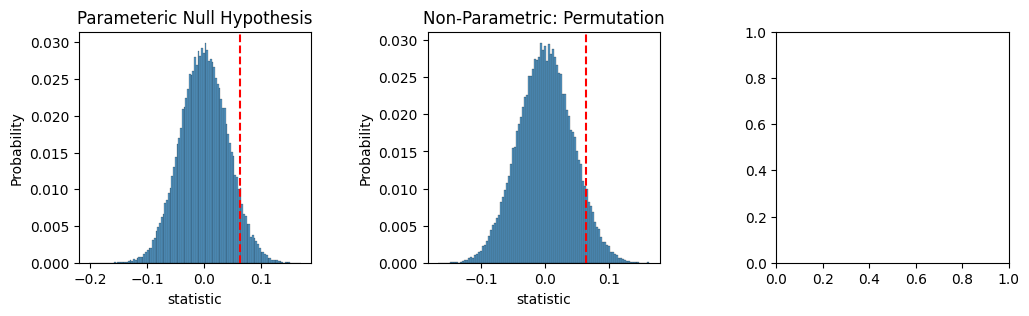

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
plt.subplots_adjust(wspace=0.5)
plot_continuous(sample_means_a, axes[0], num_bins=100)
plot_continuous(sample_means_b, axes[1], num_bins=100)

# add a vertical line at the actual mean
axes[0].axvline(actual_mean, color="red", linestyle="--")
axes[1].axvline(actual_mean, color="red", linestyle="--")
axes[0].set_title('Parameteric Null Hypothesis')
axes[1].set_title('Non-Parametric: Permutation')

In [13]:
# Nonparametric Estimation of Confidence Intervals using Bootstrap Sampling

# We can do something analogous to construct a "confidence interval" around the observed mean.
# Here, instead of simulating other samples of size 40 from a distribution based on the null hypothesis, 
# we simulate samples of size 40 by bootstrap resampling of the observed data.

# Again, for each sample we compute the mean. The interval covering 95% of the sample means is a 95% confidence interval.

# While it won't come out exactly the same, since we are using a slightly different procedure for estimating the sampling distribution, 
# we expect the proportion of values in this sampling distribution that are farther away than 0 from the observed mean should be about the 
# same as the p-values calculated based on a null hypothesis.

def bootstrap_resample(df, n_people):
    return rng.choice(df['increase'], n_people, replace=True)


In [14]:
# 2b. Simulate Sampling Distribution

sample_means_c = simulate_sampling_distribution(
    lambda n: bootstrap_resample(exp_results, n),
    lambda x: x.mean(),
    n_simulations=n_simulations,
    sample_size=40,
)

sample_means_c.describe()
exp_results

,before,after,increase
0,0.850586,1.100480,0.249894
1,1.109104,1.423502,0.314398
2,1.285461,1.098532,-0.186928
3,1.077887,1.033048,-0.044838
4,1.269408,1.238680,-0.030727
5,0.877411,1.183801,0.306390
6,1.135113,0.882174,-0.252939
7,1.112357,1.025477,-0.086880
8,0.881338,1.009378,0.128040
9,1.446061,1.240712,-0.205349


In [15]:
# 3b. Assess Surprise (Significance)

# Compute the p-value. What fraction of the sample means are farther from the true mean than 0 is?
p_value_c = (np.abs(sample_means_c["statistic"] - actual_mean) > actual_mean).mean()
p_value_c

np.float64(0.1255)

In [16]:
# Compute the 95% confidence interval
# what range covers 95% of the bootstrap samples?
lower, upper = np.percentile(sample_means_c['statistic'], [2.5, 97.5])
lower, upper

(np.float64(-0.018227315012853892), np.float64(0.1447328371992399))

Text(0.5, 1.0, 'Bootstrap CI Estimation')

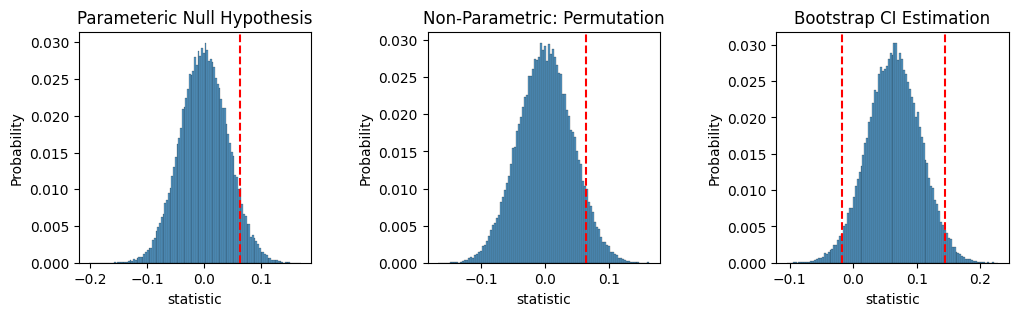

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
plt.subplots_adjust(wspace=0.5)
plot_continuous(sample_means_a, axes[0], num_bins=100)
plot_continuous(sample_means_b, axes[1], num_bins=100)
plot_continuous(sample_means_c, axes[2], num_bins=100)

# add a vertical line at the actual mean
axes[0].axvline(actual_mean, color="red", linestyle="--")
axes[1].axvline(actual_mean, color="red", linestyle="--")
axes[2].axvline(lower, color="red", linestyle="--")
axes[2].axvline(upper, color="red", linestyle="--")
axes[0].set_title('Parameteric Null Hypothesis')
axes[1].set_title('Non-Parametric: Permutation')
axes[2].set_title('Bootstrap CI Estimation')

In [18]:
# There's a connection between the 95% confidence intervals and hypothesis tests:
    # If the 95% confidence interval includes the value that the null hypothesis assumes, then the p-value with a hypothesis test will be above 5%
    #     - Here we see that the bootstrap confidence interval includes 0
    #     - Thus, you should not reject the null hypothesis
    # Conversely, if the 95% confidence interval doesn't include that, then the p-value with a hypothesis test will be below 5%
    #     - Then, you would reject the null hypothesis


# So, Does One Beer Make You Slower?

# (Remember, this is fictitious data, so don't make any real-life decisions based on it!)

# It looked like one beer made people slower, by .06 seconds on average.

# But we failed to reject the null hypothesis.

#     - Even if it there were no effect, and the before and after were two indendepent draws from each person's personal reaction time, 
#         it wouldn't be so surprising to see an average difference of .06 seconds.
#           - It would happen in about 13% of all samples of 40 people
#     - Relatedly, the bootstrap process includes 0 within the 95% confidence interval

# But beware, failure to reject the null hypothesis doesn't mean you should "accept" it!
#     - My starting intuition is that one beer does have some effect on most people's reaction times.
#     - This dataset, if it were real, would increase that belief! It certainly wouldn't make me believe that the null hypothesis is true.


In [19]:
# Statistical Inference Based on Bayesian Updating

# Classical statistical inference answers the question: how likely would I be able to see a result as extreme as the data I actually saw, given some assumed null hypothesis?

# Bayesian inference asks a different question: how should I update my initial beliefs about a data generating process, given one set of outputs I've observed of that process?

# We'll again use code that simulates distributions (data generating processes) to illustrate Bayesian inference, with our reaction times dataset:
    # We will start with a "uniform" prior belief: reaction time after a beer increases, on average, by some value in a range, but I have no idea where within that range it is.
    # For each possible value of that parameter (the average reaction time increase), there's some likelihood of producing the outcome we saw.
    # Those likelihoods collectively determine our posterior beliefs about the plausibility of those parameter values.


exp_results = pd.read_csv('data/reaction_times.csv')
exp_results['increase'] = exp_results['after'] - exp_results['before']
print(exp_results.head())
print("\n\n", exp_results['increase'].describe())

     before     after  increase
0  0.850586  1.100480  0.249894
1  1.109104  1.423502  0.314398
2  1.285461  1.098532 -0.186928
3  1.077887  1.033048 -0.044838
4  1.269408  1.238680 -0.030727


 count    40.000000
mean      0.063628
std       0.266251
min      -0.667366
25%      -0.118254
50%       0.027598
75%       0.272667
max       0.501296
Name: increase, dtype: float64


In [20]:
# Uniform Prior

# I'm going to make a parametric assumption about how a person's change in reaction is generated
#     - A person's change in reaction time is drawn from a normal distribution, which has two parameters, a mean and standard deviation:
#         * The mean is somewhere between -0.05 seconds and +0.20 seconds, with all values in that range equally plausible to me (before I see the data). 
#           My reasoning for starting with these beliefs about the mean change in reaction time is based on some past literature or personal experiences:
#             + It's possible that people actually get a little faster from Before to After, because of the practice effect. Perhaps that could be as much as 0.05 seconds.
#             + But beer makes people slower, maybe by as much 0.2 seconds
#         * The standard deviation is 0.266251, which is empirically calculated from my (fake) experiment results.

# We will operationalize our uncertainty about the mean change in reaction time as a "grid" of possible values for the mean, and then try to make inferences 
# about which of those possible values is more plausible, given the data we saw in the experiment.


actual_std = exp_results['increase'].std()
print(f"actual std dev. : {actual_std}")

# grid of possible means from -0.05 to +0.2
possible_means = np.linspace(-0.05, 0.2, 26)
print(f"\npossible means: {possible_means}")


actual std dev. : 0.26625096170556667

possible means: [-0.05 -0.04 -0.03 -0.02 -0.01  0.    0.01  0.02  0.03  0.04  0.05  0.06
  0.07  0.08  0.09  0.1   0.11  0.12  0.13  0.14  0.15  0.16  0.17  0.18
  0.19  0.2 ]


In [21]:
# Simulate Sampling Distribution for Each Possible Value of Mean

# For each possible value of the mean, we will simulate 1000 40-person samples and compute their means. In other words, for each possible value, we simulate its sampling distribution.

n_simulations = 1000

sampling_distributions = pd.DataFrame({
    'mean_change_in_reaction_time': possible_means,
    'sampling_distribution': [simulate_sampling_distribution(
                                lambda n: rng.normal(param_value, actual_std, n),
                                lambda x: x.mean(),
                                n_simulations=n_simulations,
                                sample_size=40) 
                            for param_value in possible_means]
})

sampling_distributions.head()


,mean_change_in_reaction_time,sampling_distribution
0,-0.05,statistic 0 -0.041211 1 0.013915 2...
1,-0.04,statistic 0 -0.080602 1 -0.069249 2...
2,-0.03,statistic 0 0.007349 1 -0.113383 2...
3,-0.02,statistic 0 -0.037537 1 0.052730 2...
4,-0.01,statistic 0 -0.052994 1 -0.034157 2...


In [22]:
sampling_distributions.loc[1, 'sampling_distribution'].head()


,statistic
0,-0.080602
1,-0.069249
2,0.002162
3,-0.046680
4,-0.090108


In [23]:
# Compute likelihood that each produces sample mean that we saw

# We saw a sample mean of 0.063628.

# For each of our possible_means, some of their 1000 sample means will be in the range [0.06, 0.07], where our observed sample mean is.
    # Let's count how many.

# for each sampling distribution, calculate how many of its values are in the desired range, 0.06 to 0.07.
sampling_distributions['likelihood_count'] = sampling_distributions['sampling_distribution'].apply(
    lambda df: ((df['statistic'] >= 0.06) & (df['statistic'] < 0.07)).sum())

In [24]:
# We get a sample mean in the range [0.06, .07] more often when each person's reaction time change is around 0.06 than when each person's reaction time change is 0, or 0.15.
    # remember that these counts are out of 1000 samples for each possible mean change in reaction time.

sampling_distributions

,mean_change_in_reaction_time,sampling_distribution,likelihood_count
0,-0.05,statistic 0 -0.041211 1 0.013915 2...,4
1,-0.04,statistic 0 -0.080602 1 -0.069249 2...,7
2,-0.03,statistic 0 0.007349 1 -0.113383 2...,7
3,-0.02,statistic 0 -0.037537 1 0.052730 2...,6
4,-0.01,statistic 0 -0.052994 1 -0.034157 2...,26
5,0.00,statistic 0 0.074345 1 0.004501 2...,28
6,0.01,statistic 0 0.006923 1 -0.001108 2...,48
7,0.02,statistic 0 0.027348 1 0.039606 2...,46
8,0.03,statistic 0 0.023168 1 0.078179 2...,71
9,0.04,statistic 0 -0.017457 1 0.008167 2...,91


In [25]:
# Convert those Likelihoods to Posterior Probabilities

    # We started not having any reason to think that a mean change in reaction time of 0 was more or less likely than 0.4
    # But out of our samples with underlying mean change of 0, only 21 were in the range we actually observed
    # Out of our samples with underlying mean change of 0.04, 67 were in that range
    # So our posterior belief is that 0.04 is more than three times likely to be the true underlying parameter value than 0 is.
    #     Of all the times we get a statistic in the target range, more than three times as many come from simulations with parameter 0.04 than from simulations with parameter value 0.


# normalize likelihood_count column to get probabilities
sampling_distributions['posterior_belief'] = sampling_distributions['likelihood_count'] / sampling_distributions['likelihood_count'].sum()
sampling_distributions

,mean_change_in_reaction_time,sampling_distribution,likelihood_count,posterior_belief
0,-0.05,statistic 0 -0.041211 1 0.013915 2...,4,0.003865
1,-0.04,statistic 0 -0.080602 1 -0.069249 2...,7,0.006763
2,-0.03,statistic 0 0.007349 1 -0.113383 2...,7,0.006763
3,-0.02,statistic 0 -0.037537 1 0.052730 2...,6,0.005797
4,-0.01,statistic 0 -0.052994 1 -0.034157 2...,26,0.025121
5,0.00,statistic 0 0.074345 1 0.004501 2...,28,0.027053
6,0.01,statistic 0 0.006923 1 -0.001108 2...,48,0.046377
7,0.02,statistic 0 0.027348 1 0.039606 2...,46,0.044444
8,0.03,statistic 0 0.023168 1 0.078179 2...,71,0.068599
9,0.04,statistic 0 -0.017457 1 0.008167 2...,91,0.087923


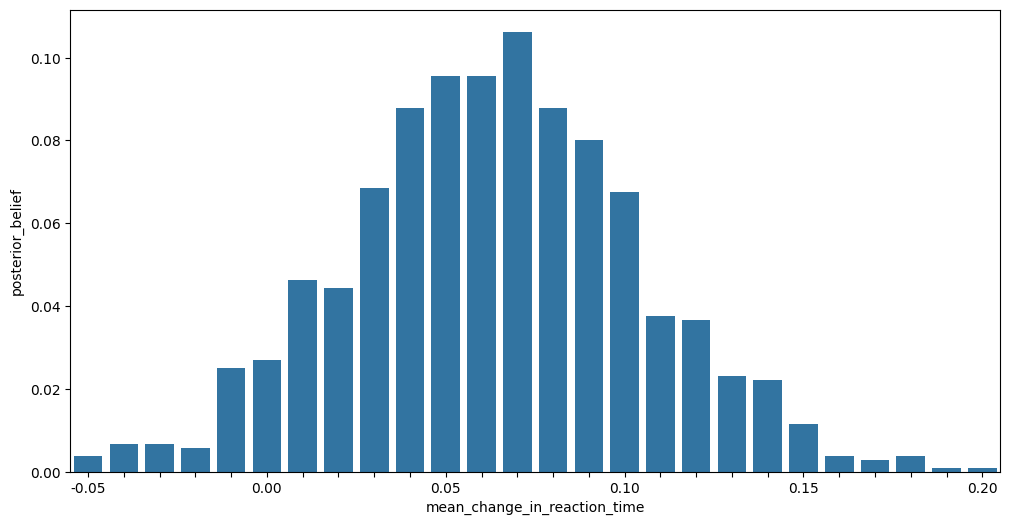

In [26]:
# plot the posterior belief as a histogram, with mean_change_in_reaction_time on the x-axis
plt.figure(figsize=(12, 6))
ax = sns.barplot(x='mean_change_in_reaction_time', y='posterior_belief', data=sampling_distributions)

# Make it display prettier...
# Get all the current x-axis tick positions
tick_positions = ax.get_xticks()

# Set every fifth label visible, hiding the rest
new_tick_labels = [f"{float(label.get_text()):.2f}" if index % 5 == 0 else '' for index, label in enumerate(ax.get_xticklabels())]

# Set the tick positions and labels
ax.set_xticks(tick_positions)  # Explicitly set tick positions
ax.set_xticklabels(new_tick_labels);  # ; suppresses some unwanted text output

In [27]:
# Compute "Credible Intervals" for the posterior belief

# A Bayesian 95%-credible interval covers 95% of the posterior belief distribution.
#     It's analogous to a 95%-confidence interval in classical statistical inference.
#     It means that you believe, given the data you've seen, there's a 95% probability that the true underlying mean lies in that range.
#     If 0 lies outside that interval, you think there's a less than 5% chance that the underlying mean is 0 or less.

# Thus, the meaning of Bayesian credible intervals is quite intuitive.
#     (They mean what one might wish classical confidence intervals would mean; but the intuitive interpretation for classical confidence intervals is not correct.)

cdf = pd.DataFrame({
    'mean_change_in_reaction_time': possible_means,
    'cumulative_posterior_belief': sampling_distributions['posterior_belief'].cumsum()
})
cdf.set_index('mean_change_in_reaction_time', inplace=True)
cdf

,cumulative_posterior_belief
mean_change_in_reaction_time,
-0.05,0.003865
-0.04,0.010628
-0.03,0.017391
-0.02,0.023188
-0.01,0.048309
0.00,0.075362
0.01,0.121739
0.02,0.166184
0.03,0.234783


In [28]:
# There is more than 6% chance that the true mean change in reaction time is 0 or less, given the data we've seen.

# find the range of values covering the middle 95% of the posterior belief
lower_bound = cdf.loc[cdf['cumulative_posterior_belief'] < 0.025].index.max()
upper_bound = cdf.loc[cdf['cumulative_posterior_belief'] > 0.975].index.min()

lower_bound, upper_bound

(np.float64(-0.020000000000000004), np.float64(0.14))

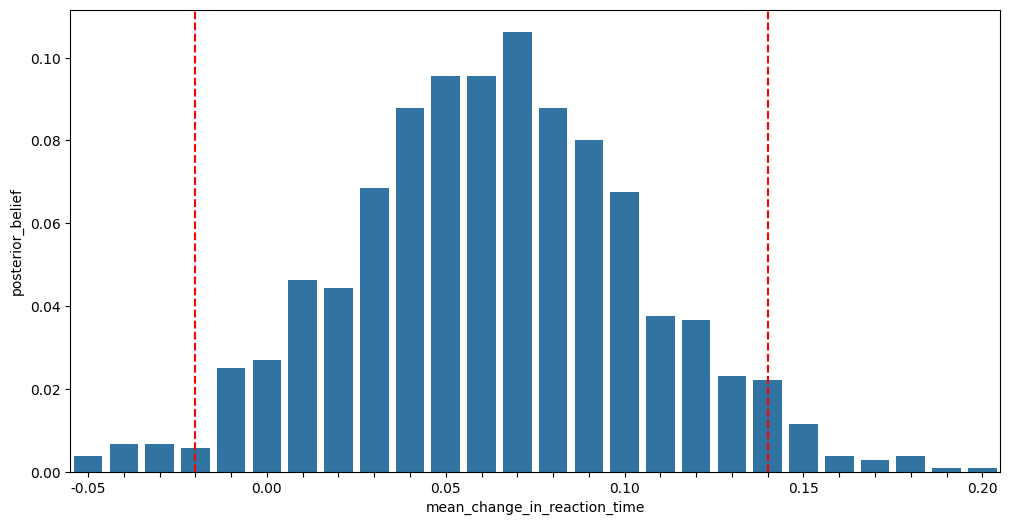

In [29]:
# plot the posterior belief as a histogram, with mean_change_in_reaction_time on the x-axis
plt.figure(figsize=(12, 6))
ax = sns.barplot(x='mean_change_in_reaction_time', y='posterior_belief', data=sampling_distributions)

# Make it display prettier...
# Get all the current x-axis tick positions
tick_positions = ax.get_xticks()

# Set every fifth label visible, hiding the rest
new_tick_labels = [f"{float(label.get_text()):.2f}" if index % 5 == 0 else '' for index, label in enumerate(ax.get_xticklabels())]

# Set the tick positions and labels
ax.set_xticks(tick_positions)  # Explicitly set tick positions
ax.set_xticklabels(new_tick_labels);  # ; suppresses some unwanted text output

# add red vertical lines at lower_bound and upper_bound
ax.axvline(cdf.index.get_loc(lower_bound), color='red', linestyle='--')
ax.axvline(cdf.index.get_loc(upper_bound), color='red', linestyle='--')

In [30]:
# Given the evidence from the experiment, our posterior belief is:

    # There is a 95% chance that the true mean change in reaction time is between (-0.03, +0.15)
    # So, we're not confident, beyond a reasonable doubt (5%) that the mean change in reaction time is greater than 0.
    #     Similar conclusion to what we found with classical hypothesis testing
    #     But with the Bayesian approach we can quantify our beliefs about the plausibility of different possible underlying 
    #     mean change in reaction time, including how big that change might be.

